In [12]:
import os
from PIL import Image
from IPython.display import display
import json
import matplotlib.pyplot as plt
import numpy as np
from experiments.zero_shot_bp import get_model_prompter


solutions = "data/solutions/bp_solutions.json"
with open(solutions, "r") as f:
    solutions_dict = json.load(f)

In [ ]:
# Set ID of Bongard problem
# -------------------------
bp_id = 8
# -------------------------
# Select model to evaluate from ["gpt-5", "gpt-4o", "o1", "o3", "gemini-1.5-pro", "gemini-2.0-flash-exp", "claude-3-5-sonnet-20241022", "LlavaOnevision", "Qwen2VL", "InternVL2_5"]
model = "gpt-5"
# -------------------------
KEY = None  # set this to your OpenAI, Google, etc. key if you want to run an API model

In [17]:
def load_bp_image(bp_id):
    # load BP image
    bp_id_str = str(bp_id).zfill(4)
    bp_image_path = f"data/bpimgs/p{bp_id_str}.png"
    bp_image = Image.open(bp_image_path)

    # display BP image
    print(f"Bongard Problem {bp_id}")
    bp_image = bp_image.resize((bp_image.size[0] // 5, bp_image.size[1] // 5))
    display(bp_image)

    # print solution for this BP
    solution = solutions_dict[str(bp_id)]
    print(f"Ground truth: {solution[0]} vs. {solution[1]}")

In [18]:
def prompt_model(bp_id, model):
    # load BP image
    bp_id_str = str(bp_id).zfill(4)
    bp_image_path = f"data/bpimgs/p{bp_id_str}.png"
    # Prompt model to solve the BP (Task 1)
    prompter = get_model_prompter(model, key=KEY)

    system_prompt_path = "prompts/bongard/system_prompt.txt"
    system_prompt = open(system_prompt_path, "r").read()

    prompt_path = "prompts/bongard/zero_shot.txt"
    prompt = open(prompt_path, "r").read()

    response = prompter.prompt_with_images(
        prompt, [bp_image_path], system_prompt=system_prompt
    )
    return response

In [19]:
def task_2(bp_id, model):
    # load BP images
    top_path = "data/bongard-problems-high-res/p" + str(bp_id).zfill(4)
    image_paths = [top_path + f"/{i}.png" for i in range(0, 12)]

    system_prompt = "You are a helpful assistant that can describe images provided by the user in extreme detail. You are able to recognize abstract concepts in images like humans do. You are helping a scientist discover relevant patterns in images."

    prompt_path = f"prompts/concepts/concept_prompt_{bp_id}.txt"
    prompt = open(prompt_path, "r").read()

    # Prompt model to classify the images (Task 2)
    prompter = get_model_prompter(model, key=KEY)

    responses = []

    for i, image_path in enumerate(image_paths):
        response = prompter.prompt_with_images(
            prompt, [image_path], system_prompt=system_prompt
        )
        responses.append(response)

    # parse the responses
    parsed_responses = []

    for response in responses:
        try:
            # parse string between {}
            response = response.split("{")[1].split("}")[0]
        except:
            response = "error"

        response = response.split(":")[-1].replace("'", "").replace('"', "").strip()

        parsed_responses.append(response)

    return parsed_responses

In [20]:
def plot_results_task_2(bp_id, model, responses, solution):

    # load BP images
    top_path = "data/bongard-problems-high-res/p" + str(bp_id).zfill(4)
    image_paths = [top_path + f"/{i}.png" for i in range(0, 12)]

    concepts = "prompts/concepts/contrary_concepts.json"
    with open(concepts, "r") as f:
        concepts_dict = json.load(f)
    # get the relevant concepts for this BP
    relevant_concepts = concepts_dict.get(str(bp_id), [])

    # plot images and responses
    fig, axs = plt.subplots(2, 6, figsize=(30, 12))
    # super title
    fig.suptitle(
        f"Bongard Problem {bp_id} - Model {model} \n {solution[0]} vs. {solution[1]}\n",
        fontsize=30,
    )

    axs = axs.flatten()
    for i, (image_path, response) in enumerate(zip(image_paths, responses)):
        image = Image.open(image_path)
        axs[i].imshow(np.array(image))

        # choose color for the response
        if i < 6 and response == relevant_concepts[0]:
            color = "green"
        elif i < 6 and response == relevant_concepts[1]:
            color = "red"
        elif i >= 6 and response == relevant_concepts[0]:
            color = "red"
        elif i >= 6 and response == relevant_concepts[1]:
            color = "green"
        else:
            color = "black"

        # title in black
        axs[i].set_title(f"Image {i+1}\nModel response:", fontsize=16, color="black")

        # colored response on its own line, centered under the title
        # position slightly below the top of the axes, adjust 'y' if you want more spacing
        axs[i].text(
            0.5,
            0.95,
            str(response),
            transform=axs[i].transAxes,
            ha="center",
            va="bottom",
            fontsize=16,
            color=color,
        )

        # override text color only for response
        axs[i].texts[-1].set_color(color)

        axs[i].axis("off")

    # remove empty subplots
    for j in range(len(image_paths), len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

Bongard Problem 8


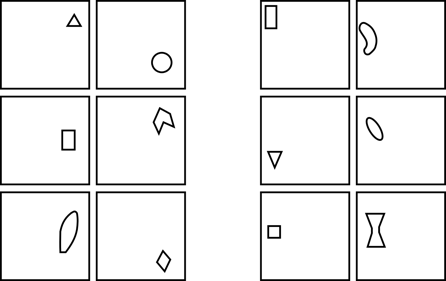

Ground truth: Figures on the right side vs. Figures on the left side


In [21]:
load_bp_image(bp_id)

In [ ]:
response = prompt_model(bp_id, model)
print(f"Model response:\n {response}")

Using model: gpt-5
Model response
: answer = {
    'set A rule': 'Each diagram shows a figure with at most one inward “dent” (zero or one concave part).',
    'set B rule': 'Each diagram shows a figure with two inward “dents” or none but elongated vertically (e.g., tall rectangle/ellipse/hourglass).'
}


Using model: gpt-5


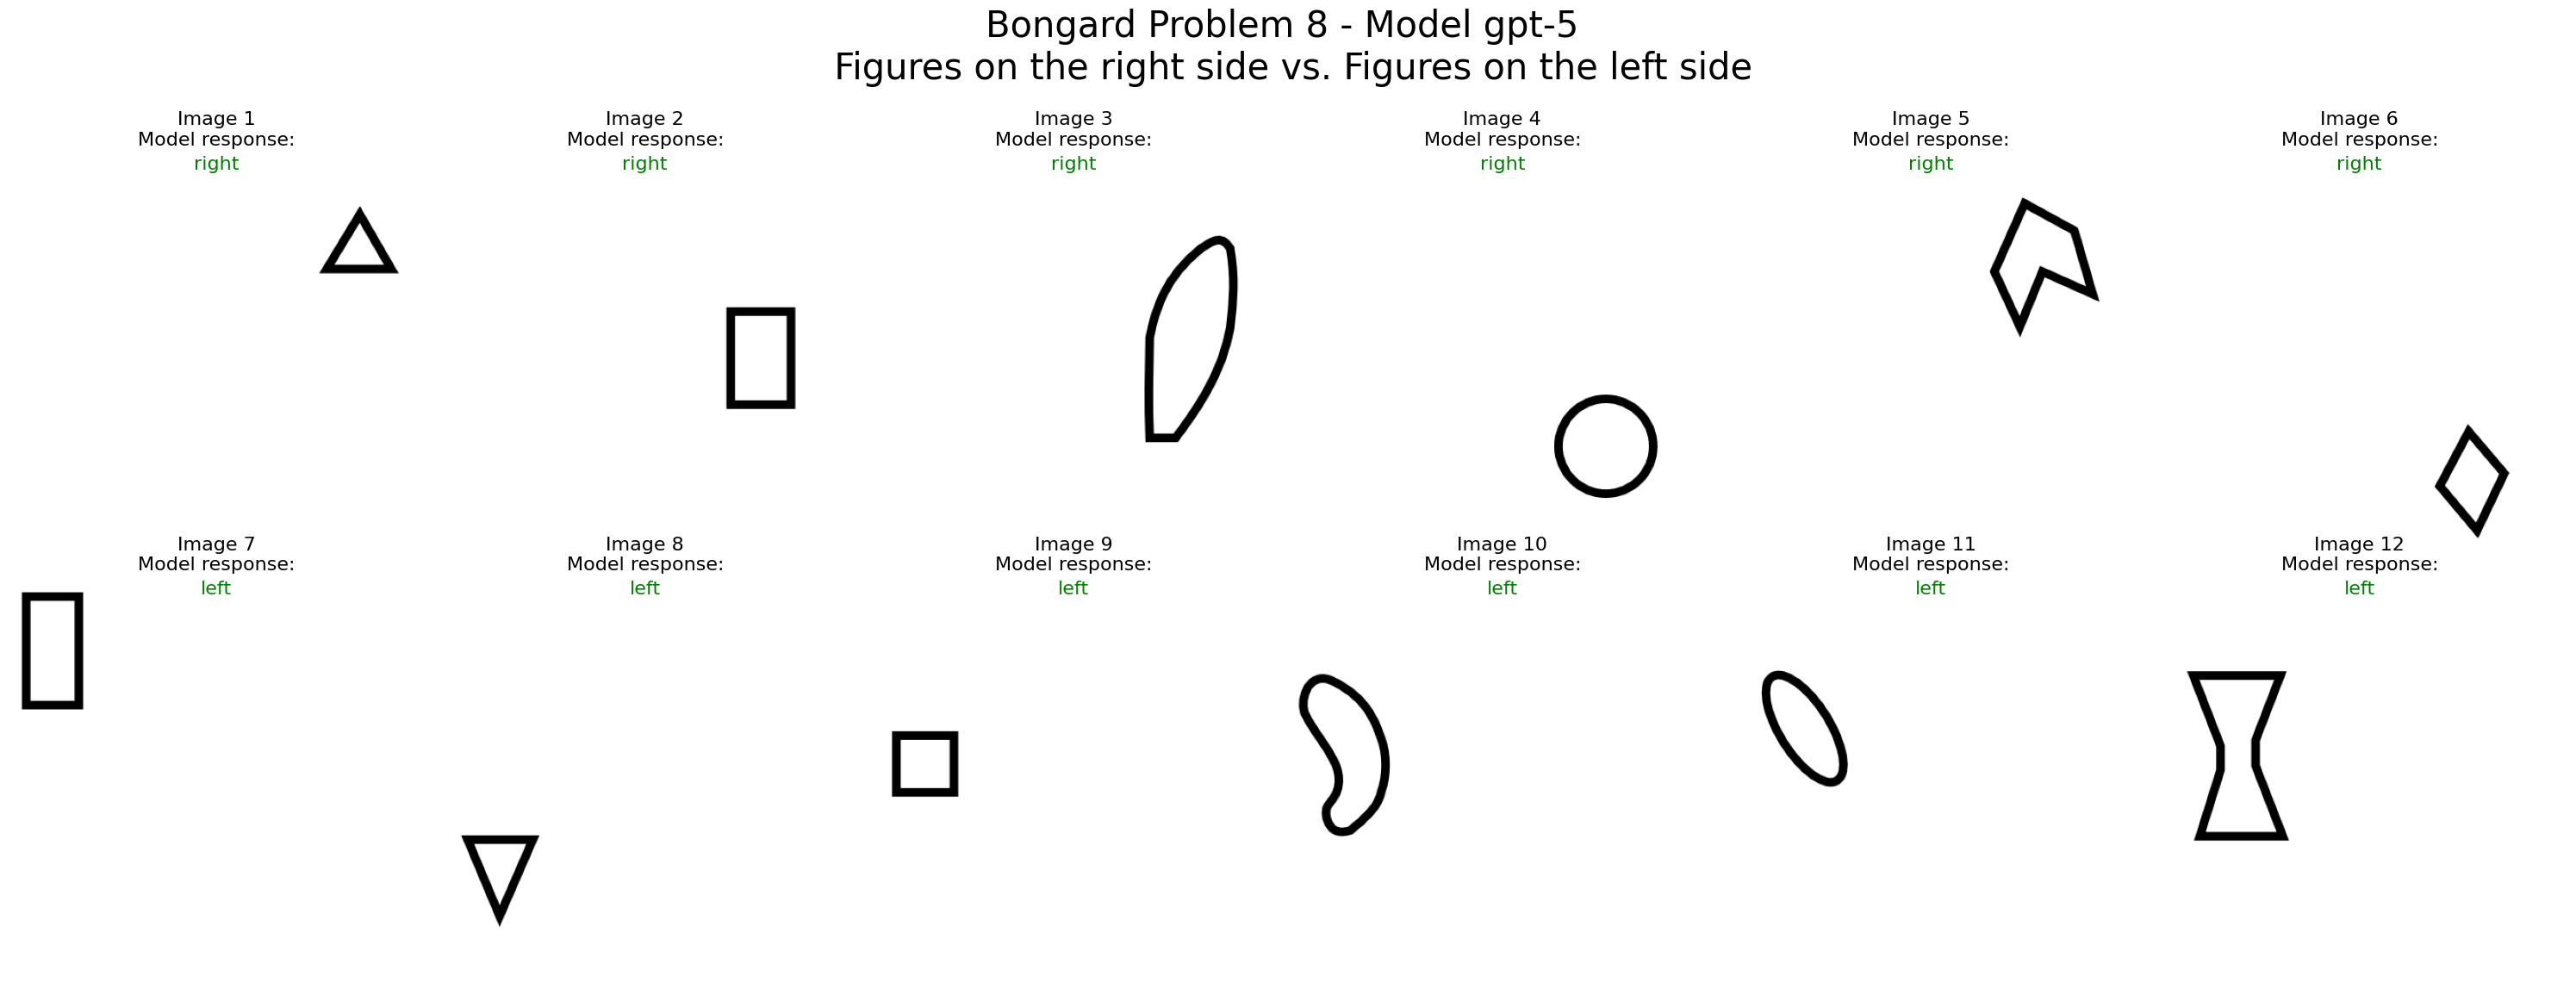

In [23]:
# Detect Concepts - Task 2
responses = task_2(bp_id, model)
plot_results_task_2(bp_id, model, responses, solutions_dict[str(bp_id)])